# Multilayer Perceptron- NSAC

In [ ]:
# Connect to Google Drive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Read data from Google Drive.
# Data is already clean.

file_path = "/content/drive/MyDrive/Doutorado CAV 2024/Análises no Colab/JSTARS_153_samples.csv"
data = pd.read_csv(file_path, decimal=',')

# Separate response and predictor variables

X = data.iloc[:, 14:221]  # Spectral bands
y = data['V_hectare']     # Volume to be predicted

In [ ]:
X.head()

,Band 1,Band 2,Band 3,Band 4,Band 5,Band 6,Band 7,Band 8,Band 9,Band 10,...,Band 198,Band 199,Band 200,Band 201,Band 202,Band 203,Band 204,Band 205,Band 206,Band 207
0,0.0151,0.0103,0.0087,0.0127,0.0118,0.0105,0.0124,0.0118,0.0132,0.0129,...,0.0274,0.0262,0.0282,0.0244,0.0253,0.0201,0.0208,0.0193,0.0188,0.0105
1,0.0141,0.0079,0.0097,0.0129,0.0105,0.0111,0.0114,0.0122,0.0132,0.0127,...,0.0273,0.0257,0.0246,0.0230,0.0252,0.0205,0.0227,0.0188,0.0203,0.0125
2,0.0102,0.0074,0.0081,0.0094,0.0096,0.0107,0.0109,0.0101,0.0118,0.0127,...,0.0275,0.0256,0.0280,0.0234,0.0224,0.0196,0.0215,0.0175,0.0183,0.0144
3,0.0128,0.0108,0.0105,0.0108,0.0103,0.0122,0.0122,0.0120,0.0126,0.0126,...,0.0276,0.0241,0.0281,0.0243,0.0221,0.0220,0.0204,0.0177,0.0187,0.0138
4,0.0128,0.0106,0.0095,0.0103,0.0095,0.0126,0.0130,0.0110,0.0120,0.0138,...,0.0267,0.0254,0.0251,0.0251,0.0226,0.0192,0.0208,0.0170,0.0187,0.0123


In [ ]:
y.head()

,V_hectare
0,359.184
1,377.143
2,343.643
3,320.322
4,380.408


# Multilayer Perceptron(MLP)

In [ ]:
pip install keras-tuner

In [ ]:
import numpy as np
import tensorflow as tf
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import time


A KerasTuner function in a separate module was used to automate the search for the best hyperparameters for a Multilayer Perceptron (MLP) neural network, identifying optimal values ​​for the number of layers, number of neurons, learning rate, and activation functions. The best parameters have already been incorporated into the MLP network shown below.

Shape of X_train_mlp: (122, 207)
Shape of X_test_mlp: (31, 207)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,945 (386.50 KB)

 Trainable params: 97,537 (381.00 KB)

 Non-trainable params: 1,408 (5.50 KB)


Starting MLP training...
Epoch 86: early stopping
Restoring model weights from the end of the best epoch: 66.
Training time: 14.4818 seconds

Training stopped at epoch 86. Best model weights restored from epoch 66 (0-indexed: 65).

Evaluating the model on the training set...
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
R² (MLP Training): 0.747
RMSE (MLP Training): 56.97
MAE (MLP Training): 46.04
RRMSE (MLP Training): 13.27%

Evaluating the model on the test set...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Test time: 0.1536 seconds
R² (MLP Test): 0.642
RMSE (MLP Test): 64.00
MAE (MLP Test): 49.99
RRMSE (MLP Test): 15.36%

Difference (R² Training - R² Test): 0.1056


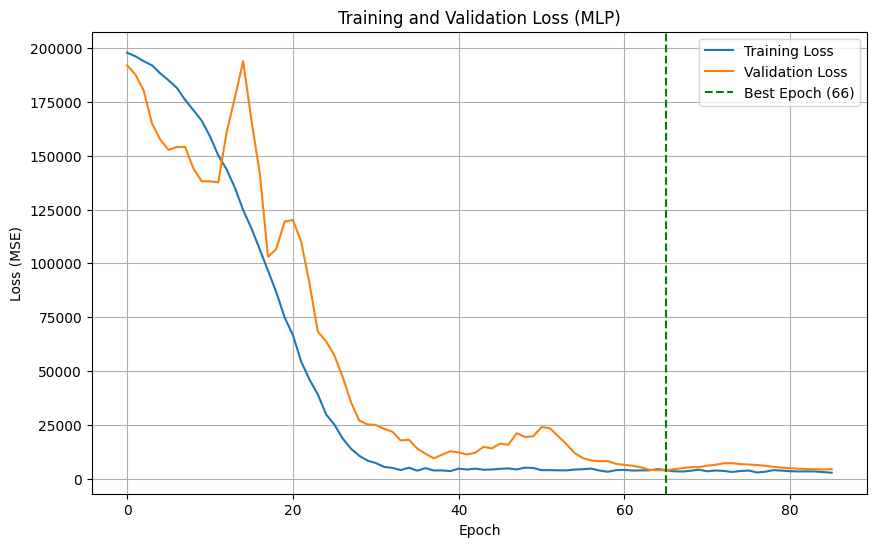

In [ ]:
# Data Preparation ---
# X and y data should already be loaded from previous cells.
# X: DataFrame of spectral bands
# y: Series of wood volume

# ==============================================================================
# 1. Preprocessing
# ==============================================================================

# Set random seeds for reproducibility across runs, especially for data splitting.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Data normalization for predictor variables (X - reflectances)
# StandardScaler standardizes features by removing the mean and scaling to unit variance.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and test sets.
# A test size of 20% means 20% of the data will be used for testing, and 80% for training.
X_train_mlp, X_test_mlp, y_train_mlp, y_test_mlp = train_test_split(X_scaled, y, test_size=0.2, random_state=SEED)

print(f"Shape of X_train_mlp: {X_train_mlp.shape}")
print(f"Shape of X_test_mlp: {X_test_mlp.shape}")

# ==============================================================================
# 2. Model Architecture Definition
# ==============================================================================

# Define the MLP model architecture. This model is based on hyperparameter tuning
# results from KerasTuner to find the optimal configuration.
def build_mlp_model(input_shape):
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        # Dense layer with ReLU activation and L2 regularization to prevent overfitting.
        layers.Dense(units=64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.0001)),
        # Batch Normalization normalizes the activations of the previous layer at each batch,
        # i.e. applies a transformation that maintains the mean activation close to 0 and the activation standard deviation close to 1.
        layers.BatchNormalization(),
        # Dropout layer randomly sets a fraction of input units to 0 at each update during training,
        # which helps prevent overfitting.
        layers.Dropout(0.4),

        layers.Dense(units=256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(units=128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.1),

        layers.Dense(units=256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(units=1, activation='linear') # Output layer for regression tasks (predicting a single continuous value).
    ])
    return model


# Instantiate and compile the model.
input_shape = (X_train_mlp.shape[1],)
mlp_model = build_mlp_model(input_shape)

# Compile the model using 'mse' (Mean Squared Error) as the loss function for regression,
# and 'adam' as the optimizer with a learning rate of 0.01 (optimized by KerasTuner).
mlp_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

# Display a summary of the model's architecture, including layer types, output shapes, and number of parameters.
mlp_model.summary()

# ==============================================================================
# 3. Model Training
# ==============================================================================

print("\nStarting MLP training...")

# Define callbacks for training control:
# EarlyStopping: Stops training when a monitored metric (validation loss) has stopped improving for 'patience' epochs.
# RestoreBestWeights: Restores model weights from the epoch with the best value of the monitored metric.
# ReduceLROnPlateau: Reduces the learning rate when the validation loss has stopped improving for 'patience' epochs.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=10,
        min_lr=1e-6
    )
]

start_train_time = time.perf_counter()
# Train the model using the training data.
# epochs: Number of complete passes through the training dataset.
# batch_size: Number of samples per gradient update.
# validation_split: Fraction of the training data to be used as validation data.
# verbose=0: Suppress output for each epoch.
history_mlp = mlp_model.fit(
    X_train_mlp, y_train_mlp,
    epochs=400,            # Max number of epochs (could be stopped earlier by EarlyStopping)
    batch_size=32,         # Batch size for training
    validation_split=0.2,  # Use 20% of the training data for validation during training
    callbacks=callbacks,
    verbose=0              # Suppress epoch-by-epoch output
)
end_train_time = time.perf_counter()
print(f"Training time: {end_train_time - start_train_time:.4f} seconds")

# Find the epoch with the best validation loss to understand when EarlyStopping might have triggered.
best_epoch = np.argmin(history_mlp.history['val_loss']) + 1
print(f"\nTraining stopped at epoch {history_mlp.epoch[-1] + 1}. Best model weights restored from epoch {best_epoch} (0-indexed: {best_epoch - 1}).")

# The following lines are commented out as they were likely for debugging/inspection of KerasTuner results.
# print("Best hyperparameters:")
# for key in mlp_model.values:
#     print(f"{key}: {mlp_model.get(key)}")


# ==============================================================================
# 4. Model Evaluation
# ==============================================================================
# Evaluate the trained model's performance on both training and test datasets.

print("\nEvaluating the model on the training set...")
# Generate predictions for the training set.
predictions_train_mlp = mlp_model.predict(X_train_mlp)

# Calculate performance metrics for the training set.
# R2 (R-squared): Coefficient of determination, measures the proportion of the variance in the dependent variable
# that is predictable from the independent variables.
r2_train_mlp = r2_score(y_train_mlp, predictions_train_mlp)
# RMSE (Root Mean Squared Error): Measures the average magnitude of the errors. It's the square root of the average of squared differences between prediction and actual observation.
rmse_train_mlp = np.sqrt(mean_squared_error(y_train_mlp, predictions_train_mlp))
# MAE (Mean Absolute Error): Measures the average magnitude of the errors, without considering their direction.
mae_train_mlp = mean_absolute_error(y_train_mlp, predictions_train_mlp)
# RRMSE (Relative Root Mean Squared Error): RMSE expressed as a percentage of the mean of the observed values.
rrmse_train_mlp = (rmse_train_mlp / np.mean(y_train_mlp)) * 100

print(f"R\u00b2 (MLP Training): {r2_train_mlp:.3f}")
print(f"RMSE (MLP Training): {rmse_train_mlp:.2f}")
print(f"MAE (MLP Training): {mae_train_mlp:.2f}")
print(f"RRMSE (MLP Training): {rrmse_train_mlp:.2f}%")


print("\nEvaluating the model on the test set...")
start_test_time = time.perf_counter()
# Generate predictions for the unseen test set.
predictions_test_mlp = mlp_model.predict(X_test_mlp)
end_test_time = time.perf_counter()
print(f"Test time: {end_test_time - start_test_time:.4f} seconds")

# Calculate performance metrics for the test set.
r2_test_mlp = r2_score(y_test_mlp, predictions_test_mlp)
rmse_test_mlp = np.sqrt(mean_squared_error(y_test_mlp, predictions_test_mlp))
mae_test_mlp = mean_absolute_error(y_test_mlp, predictions_test_mlp)
rrmse_test_mlp = (rmse_test_mlp / np.mean(y_test_mlp)) * 100

print(f"R\u00b2 (MLP Test): {r2_test_mlp:.3f}")
print(f"RMSE (MLP Test): {rmse_test_mlp:.2f}")
print(f"MAE (MLP Test): {mae_test_mlp:.2f}")
print(f"RRMSE (MLP Test): {rrmse_test_mlp:.2f}%")

# Compare R-squared values between training and test sets to check for overfitting or underfitting.
print(f"\nDifference (R\u00b2 Training - R\u00b2 Test): {r2_train_mlp - r2_test_mlp:.4f}")

# --- Plot training history ---
# Visualize the training and validation loss over epochs to monitor model convergence and identify overfitting.
plt.figure(figsize=(10, 6))
plt.plot(history_mlp.history['loss'], label='Training Loss')
plt.plot(history_mlp.history['val_loss'], label='Validation Loss')
# Highlight the epoch where the best validation loss was achieved (and weights were restored).
plt.axvline(x=best_epoch - 1, color='green', linestyle='--', label=f'Best Epoch ({best_epoch})')
plt.title('Training and Validation Loss (MLP)')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Permutation Importance (PIM) - Without PCA applied

Calculating Permutation Importance...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Permutation Importance calculation complete.

Top 10 most important bands:
         Band  Importance
4      Band 5    0.035530
16    Band 17    0.027929
188  Band 189    0.027573
56    Band 57    0.025561
76    Band 77    0.023243
202  Band 203    0.022837
57    Band 58    0.022505
61    Band 62    0.021040
17    Band 18    0.020946
59    Band 60    0.020069


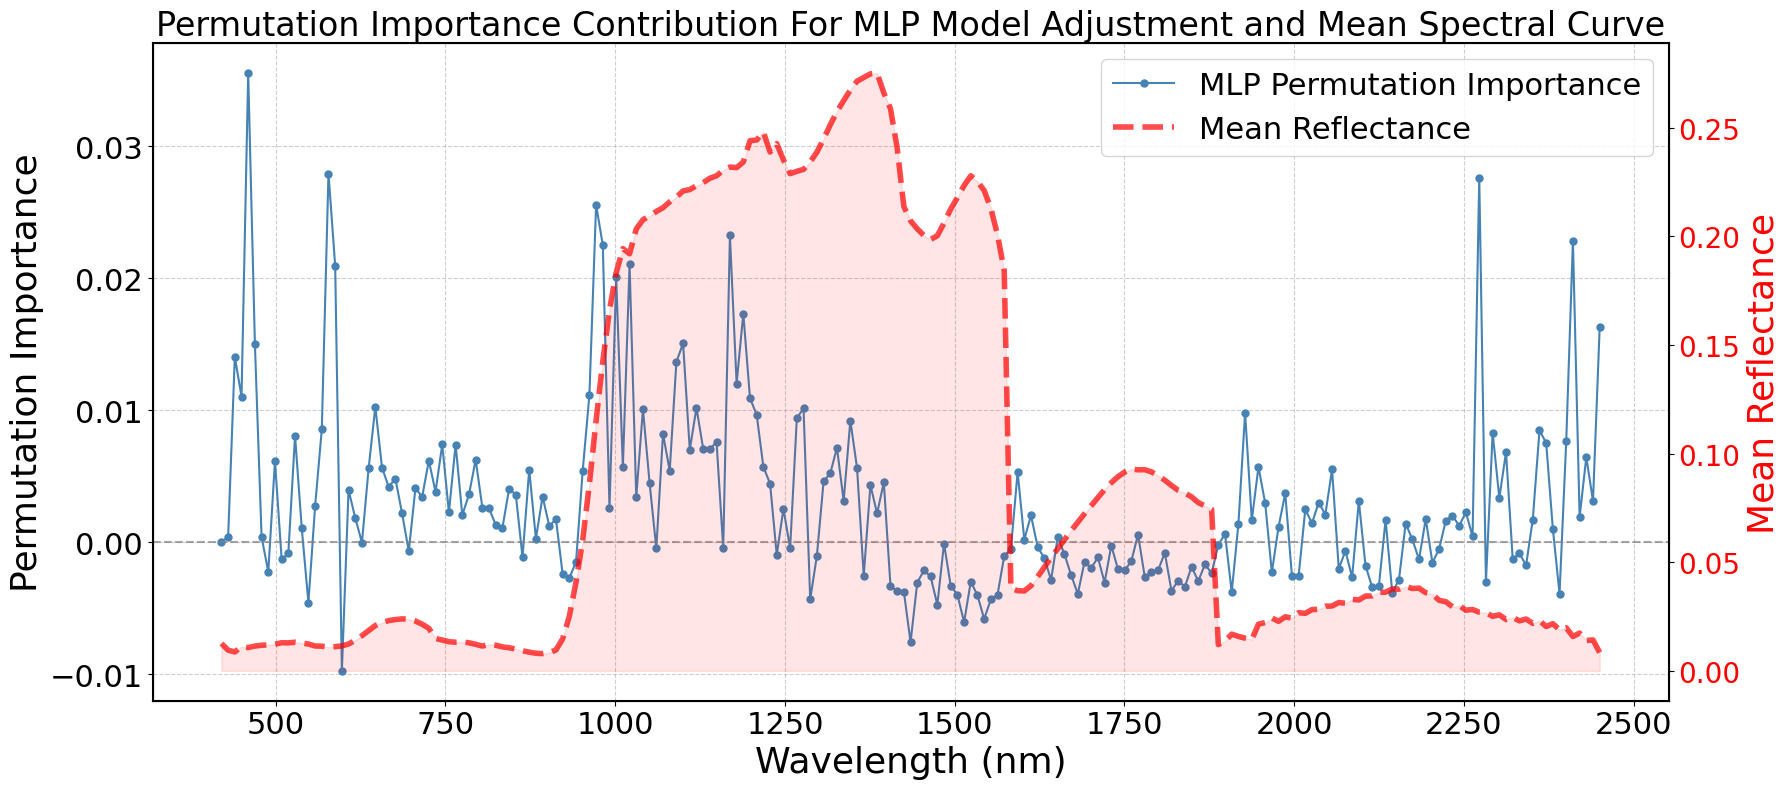

In [ ]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd # Added pandas import for DataFrame creation
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, RegressorMixin # Import for scikit-learn compatibility

# ==============================================================================
# Calculate and Plot Band Importance
# Method: Permutation Importance (PEI)
# ==============================================================================

# --- Calculate Permutation Importance ---
# The test dataset is used here because the model has not seen this data during training,
# which helps assess the model's generalized performance and feature importance.

# Wrapper class to make the Keras model compatible with scikit-learn's API.
# This is necessary because `permutation_importance` expects a scikit-learn estimator.
class KerasMLPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y=None):
        # The Keras model is already trained, so this method does nothing new.
        return self

    def predict(self, X):
        # The `mlp_model` expects X_scaled (2D input), which `permutation_importance` passes.
        # .flatten() is used to convert the (n_samples, 1) output to a 1D array.
        return self.model.predict(X).flatten()

print("Calculating Permutation Importance...")

# Instantiate the wrapper with the already trained MLP model.
mlp_wrapper = KerasMLPWrapper(mlp_model)

# Calculate permutation importance.
# `scoring='r2'` evaluates performance using the R-squared metric.
# `n_repeats` specifies the number of times a feature is randomly permuted.
# `random_state` ensures reproducibility.
# `n_jobs=-1` uses all available CPU cores for parallel processing.
perm_importance_mlp = permutation_importance(
    mlp_wrapper, # Use the wrapper here for scikit-learn compatibility
    X_test_mlp, y_test_mlp, scoring='r2', n_repeats=10, random_state=SEED, n_jobs=-1
)
print("Permutation Importance calculation complete.")

# --- Process and Display Importance Results ---
# Get the mean importance values for each feature (band).
mean_importances_mlp = perm_importance_mlp.importances_mean

# Create a list of band names (e.g., "Band 1", "Band 2", ...).
bands_names = [f"Band {i+1}" for i in range(X.shape[1])]

# Create a DataFrame to store band names and their importance scores.
df_importance_mlp = pd.DataFrame({
    'Band': bands_names,
    'Importance': mean_importances_mlp
})

# Sort the DataFrame by importance in descending order for better visualization
# of the most impactful features.
df_importance_mlp = df_importance_mlp.sort_values(by='Importance', ascending=False)

print("\nTop 10 most important bands:")
print(df_importance_mlp.head(10))

# --- Plotting for MLP Permutation Importance and Mean Spectral Curve ---

# 1. Define EnMAP wavelengths for the 207 bands, assuming a linear distribution
# from 420 nm to 2450 nm, which is typical for hyperspectral data.
enmap_wavelengths = np.linspace(420, 2450, X.shape[1])

# 2. Calculate the mean spectral curve (mean reflectance for each band) from the original X data.
# This provides context for where important bands lie on the spectrum.
mean_spectral_curve = X.mean(axis=0)

# 3. Create the plot with a secondary y-axis to display both permutation importance and reflectance.
fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot MLP Permutation Importances on the primary y-axis (ax1).
# `mean_importances_mlp` is already ordered by band number.
ax1.plot(
    enmap_wavelengths,
    mean_importances_mlp,
    label='MLP Permutation Importance',
    color='steelblue',
    linewidth=1.5,
    marker='o',
    markersize=5
)

# Add a horizontal line at y=0 to easily see positive vs. negative importances.
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.7)
ax1.set_xlabel('Wavelength (nm)', fontsize=26)
ax1.set_ylabel('Permutation Importance', fontsize=26, color='black')
ax1.tick_params(axis='y', labelcolor='black', labelsize=22)
ax1.tick_params(axis='x', labelsize=22)
ax1.grid(True, linestyle='--', alpha=0.6)

# Create a second y-axis (ax2) to plot the mean spectral curve.
ax2 = ax1.twinx()
ax2.plot(enmap_wavelengths, mean_spectral_curve, label='Mean Reflectance', color='red', linestyle='--', linewidth=4, alpha=0.7)
# Fill the area under the mean spectral curve for better visual representation.
ax2.fill_between(enmap_wavelengths, mean_spectral_curve, color='red', alpha=0.1)
ax2.set_ylabel('Mean Reflectance', fontsize=26, color='red')
ax2.tick_params(axis='y', labelcolor='red', labelsize=20)

# Combine legends from both axes to appear in a single legend box.
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right', frameon=True, fontsize=22)

ax1.set_title('Permutation Importance Contribution For MLP Model Adjustment and Mean Spectral Curve', fontsize=24)

# Make plot border lines darker for improved aesthetics.
ax1.spines['left'].set_edgecolor('black')
ax1.spines['left'].set_linewidth(1.5)
ax1.spines['bottom'].set_edgecolor('black')
ax1.spines['bottom'].set_linewidth(1.5)
ax2.spines['right'].set_edgecolor('black')
ax2.spines['right'].set_linewidth(1.5)
ax2.spines['top'].set_edgecolor('black')
ax2.spines['top'].set_linewidth(1.5)

plt.tight_layout() # Adjusts plot to prevent labels from overlapping.
# Save the plot with a high resolution for quality output.
plt.savefig('permutation_importance_mlp.png', dpi=600)
plt.show()

Observed vs Predict

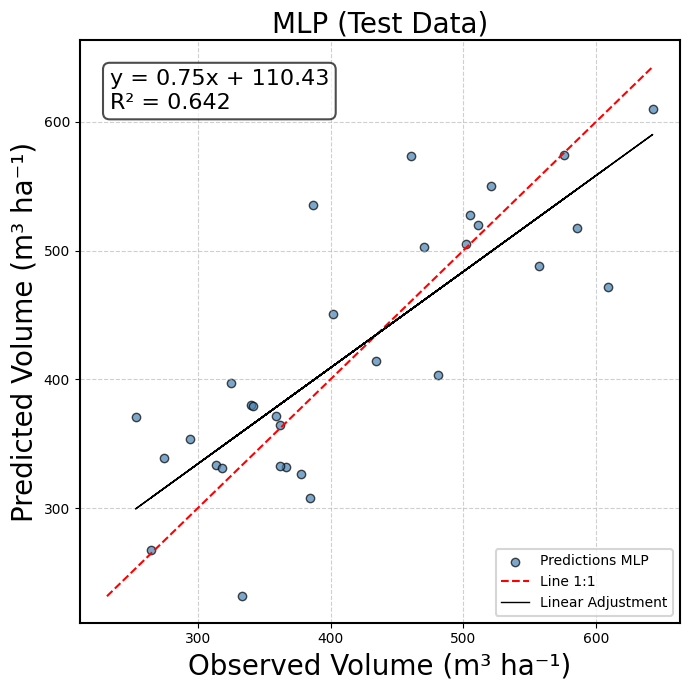

In [ ]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# ==============================================================================
# Plot Observed vs. Predicted Values for the Test Set
# ==============================================================================

# Create a new figure with a specific size for the scatter plot.
plt.figure(figsize=(7, 7))

# Plot the scatter points: observed values (y_test_mlp) against predicted values (predictions_test_mlp).
plt.scatter(y_test_mlp, predictions_test_mlp,
            color='steelblue',      # Color of the scatter points
            edgecolor='k',          # Edge color of the markers
            alpha=0.7,              # Transparency of the points
            label='Predictions MLP') # Label for the legend

# --- Plot 1:1 Line (Perfect Prediction Line) ---
# Determine the minimum and maximum values across both observed and predicted data
# to set the range for the 1:1 line, ensuring it spans the entire data range.
min_val_plot = min(y_test_mlp.min(), predictions_test_mlp.min())
max_val_plot = max(y_test_mlp.max(), predictions_test_mlp.max())
plt.plot([min_val_plot, max_val_plot], [min_val_plot, max_val_plot],
         'r--',                   # Red dashed line style
         label='Line 1:1',        # Label for the legend
         linewidth=1.5)           # Line width

# --- Fit a Simple Linear Regression Line for Visualization ---
# This line shows the general trend between observed and predicted values,
# helping to visualize potential bias or under/over-prediction.
reg_line_mlp = LinearRegression()
# Reshape the input data to be 2D as required by `reg_line_mlp.fit()`.
reg_line_mlp.fit(y_test_mlp.values.reshape(-1, 1), predictions_test_mlp.reshape(-1, 1))

# Extract the slope and intercept of the fitted regression line.
slope_mlp = reg_line_mlp.coef_[0][0]
intercept_mlp = reg_line_mlp.intercept_[0]

# Generate y-values for the fitted regression line.
y_fit_mlp = reg_line_mlp.predict(y_test_mlp.values.reshape(-1, 1))

# Plot the fitted linear regression line.
plt.plot(y_test_mlp, y_fit_mlp,
         color='black',            # Color of the regression line
         linewidth=1,              # Line width
         label='Linear Adjustment') # Label for the legend

# --- Add Equation and R² to the Plot ---
# Format the equation and R-squared value for display on the plot.
eq_text_mlp = f"y = {slope_mlp:.2f}x + {intercept_mlp:.2f}\nR² = {r2_test_mlp:.3f}"
plt.text(0.05, 0.95, eq_text_mlp,
         transform=plt.gca().transAxes, # Position text relative to the axes
         fontsize=16,                   # Font size of the text
         verticalalignment='top',       # Align text to the top
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, linewidth=1.5)) # Text box style

# --- Plot Configuration and Styling ---
# Set axis labels and title with specified font sizes.
plt.xlabel('Observed Volume (m³ ha⁻¹)', fontsize=20) # Using Unicode for superscript 3 and minus 1
plt.ylabel('Predicted Volume (m³ ha⁻¹)', fontsize=20)
plt.title('MLP (Test Data)', fontsize=20)

# Configure the legend: ensure a frame is drawn and set its line width.
legend = plt.legend(frameon=True)
legend.get_frame().set_linewidth(1.5)

# Add a grid to the plot for better readability.
plt.grid(True, linestyle='--', alpha=0.6)

# Make plot border lines darker for enhanced visual presence.
ax = plt.gca() # Get the current axes object.
for spine in ax.spines.values():
    spine.set_edgecolor('black') # Set the color of the spine (border)
    spine.set_linewidth(1.5)     # Increase the line width for a darker border

# Adjust plot layout to prevent labels from overlapping.
plt.tight_layout()
# Save the generated plot to a file with high resolution (600 dpi).
plt.savefig('mlp_test_data.png', dpi=600)
# Display the plot.
plt.show()

# Cross-Validation

Cross-validation with 5 repetitions was also used to verify the performance of the standard cross-validation, although this is not shown in the final metrics presented in the graphs.

In [ ]:
!pip install -q scikeras

In [ ]:
!pip uninstall -y scikit-learn scikeras
!pip install scikit-learn==1.4.2
!pip install scikeras==0.13.0
print("Restart the runtime environment (Runtime -> Restart runtime)")
print("After restarting, run the data loading cells")


Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
Found existing installation: scikeras 0.13.0
Uninstalling scikeras-0.13.0:
  Successfully uninstalled scikeras-0.13.0
  Using cached scikit-learn-1.4.2.tar.gz (7.8 MB)
  error: subprocess-exited-with-error
  
  × pip subprocess to install build dependencies did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Installing build dependencies ... error
error: subprocess-exited-with-error

× pip subprocess to install build dependencies did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
Using cached scikeras-0.13.0-py3-none-any.whl (26 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 

Reinicie o ambiente de execução (Runtime -> Restart runtime) após executar esta célula.
Depois de reiniciar, execute as células de carregamento de dados (e quaisquer outras dependências) novamente antes de tentar a validação cruzada.


Performing cross-validation for MLP model...


Average training (fit) time: 19.3706 seconds
Average test (score) time: 0.4454 seconds

--- Global Metrics (from cross_val_predict) ---
  R²: 0.601
  RMSE: 71.56
  MSE: 5120.29
  MAE: 58.65
  RRMSE: 16.66%

--- Per-Fold Metrics (from cross_val_score) ---
  Mean R²: 0.5348
  Std R²: 0.1804
  Range R²: 0.1138 - 0.7768
  Mean RMSE: 69.9351
  Std RMSE: 14.7174
  Range RMSE: 47.9499 - 91.8193


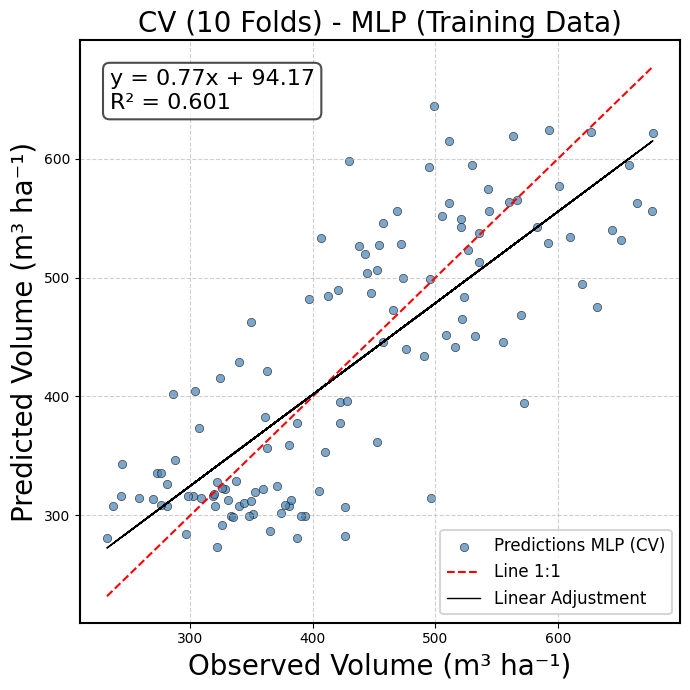

In [ ]:
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score, train_test_split, cross_validate # Removed RepeatedKFold as not used directly
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf
import random

# Ensure X and y are defined for the cell's context.
# These are loaded from previous cells, but are explicitly included here to avoid NameError
# Changed 'dados' to 'data' for consistency with previous data loading.
X = data.iloc[:, 14:221]  # Spectral bands
y = data['V_hectare']     # Volume to be predicted

# ==============================================================================
# 1. Preprocessing and Model Configuration for Cross-Validation
# ==============================================================================

# Set random seeds for reproducibility across runs.
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

# Split the dataset. For cross-validation, only the training subset of the main
# split is used. The test set from this split (second X and y) is discarded.
# This ensures that cross-validation is performed only on data the final model will train on.
X_train_raw_cv, _, y_train_cv, _ = train_test_split(X, y, test_size=0.2, random_state=SEED)

# Hyperparameter configuration previously found by KerasTuner.
best_hp_values = {
    'num_layers': 4,
    'units_0': 64,
    'l2': 0.0001,
    'dropout_0': 0.4,
    'units_1': 256,
    'dropout_1': 0.3, # Adjusting dropout can sometimes improve performance
    'learning_rate': 0.01,
    'units_2': 128,
    'dropout_2': 0.1,
    'units_3': 256,
    'dropout_3': 0.5,
}

# Define the MLP model architecture for cross-validation.
# This function will be called by KerasRegressor to build a fresh model for each fold.
def build_mlp_model_cv():
    input_shape = (X_train_raw_cv.shape[1],) # Input shape derived from the raw training data for CV
    model = keras.Sequential()
    model.add(keras.Input(shape=input_shape))

    # Layer 0: Dense layer with ReLU activation and L2 regularization to prevent overfitting.
    model.add(layers.Dense(units=best_hp_values['units_0'], activation='relu',
                           kernel_regularizer=keras.regularizers.l2(best_hp_values['l2'])))
    model.add(layers.BatchNormalization()) # Normalizes activations, speeding up training and improving stability.
    model.add(layers.Dropout(best_hp_values['dropout_0'])) # Randomly sets input units to 0 to prevent overfitting.

    # Layer 1
    model.add(layers.Dense(units=best_hp_values['units_1'], activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(best_hp_values['dropout_1']))

    # Layer 2
    model.add(layers.Dense(units=best_hp_values['units_2'], activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(best_hp_values['dropout_2']))

    # Layer 3
    model.add(layers.Dense(units=best_hp_values['units_3'], activation='relu'))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(best_hp_values['dropout_3']))

    # Output layer: A single unit with linear activation for regression tasks.
    model.add(layers.Dense(units=1, activation='linear'))

    # Compile the model with Adam optimizer, mean squared error loss, and mean absolute error metric.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_hp_values['learning_rate']),
        loss='mse',
        metrics=['mae']
    )
    return model

# Callbacks (commented out, as they might not be needed for short CV training or could complicate KerasRegressor setup)
# Callbacks are typically used for monitoring training and adjusting learning rates or stopping early.
# callbacks = [
#     keras.callbacks.EarlyStopping(
#         monitor='val_loss',
#         patience=20,
#         restore_best_weights=True
#     ),
#     keras.callbacks.ReduceLROnPlateau(
#         monitor='val_loss',
#         factor=0.5,
#         patience=10,
#         min_lr=1e-6
#     )
# ]

# Instantiate the KerasRegressor wrapper.
# This allows the Keras model to be used with scikit-learn's cross-validation tools.
mlp_keras_regressor = KerasRegressor(
    model=build_mlp_model_cv,
    epochs=100, # Number of training epochs per fold (adjust as needed)
    batch_size=32,
    verbose=0,  # Suppress verbose output during training for cleaner execution
    random_state=SEED,
    #callbacks=callbacks # Uncomment to use callbacks if necessary
)

# Create a Pipeline to standardize data and then apply the MLP model.
# StandardScaler ensures features have zero mean and unit variance, which is crucial for NNs.
pipeline_mlp_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', mlp_keras_regressor)
])

# ==============================================================================
# 2. Cross-Validation Training and Prediction
# ==============================================================================

# Define the cross-validation strategy for `cross_val_predict`.
# KFold splits data into 10 folds, shuffles it, and ensures reproducibility.
cv_predict = KFold(n_splits=10, shuffle=True, random_state=SEED)

# Define the cross-validation strategy for `cross_val_score` and `cross_validate`.
# Using the same KFold strategy for consistency. RepeatedKFold could be used for more robust estimation.
cv_score = cv_predict # Using traditional KFold (10 folds)

print("Performing cross-validation for MLP model...")

# Perform cross-validation and get predictions for each sample.
# `n_jobs=1` is used to avoid multiprocessing serialization issues with Keras models.
y_pred_cv_mlp = cross_val_predict(pipeline_mlp_cv, X_train_raw_cv, y_train_cv, cv=cv_predict, n_jobs=1)

# Perform cross-validation to get training and scoring times.
# `n_jobs=-1` attempts to use all available CPU cores. Be cautious with Keras models due to serialization.
result_temp_cv_mlp = cross_validate(pipeline_mlp_cv, X_train_raw_cv, y_train_cv, cv=cv_score, n_jobs=-1)

print(f"Average training (fit) time: {result_temp_cv_mlp['fit_time'].mean():.4f} seconds")
print(f"Average test (score) time: {result_temp_cv_mlp['score_time'].mean():.4f} seconds")


# ==============================================================================
# 3. Cross-Validation Metrics
# ==============================================================================

# Get per-fold R² and RMSE scores.
# `n_jobs=1` is used to avoid multiprocessing serialization issues with Keras models.
cv_scores_r2_mlp = cross_val_score(pipeline_mlp_cv, X_train_raw_cv, y_train_cv, cv=cv_score, scoring='r2', n_jobs=1)
cv_scores_rmse_mlp = -cross_val_score(pipeline_mlp_cv, X_train_raw_cv, y_train_cv, cv=cv_score, scoring='neg_root_mean_squared_error', n_jobs=1) # Negative sign to convert negative RMSE to positive.

# Calculate global metrics from the `cross_val_predict` results.
# These metrics represent the overall performance across all folds.
r2_global_cv_mlp = r2_score(y_train_cv, y_pred_cv_mlp)
rmse_global_cv_mlp = np.sqrt(mean_squared_error(y_train_cv, y_pred_cv_mlp))
mse_global_cv_mlp = mean_squared_error(y_train_cv, y_pred_cv_mlp)
mae_global_cv_mlp = mean_absolute_error(y_train_cv, y_pred_cv_mlp)
rrmse_global_cv_mlp = (rmse_global_cv_mlp / np.mean(y_train_cv)) * 100

print("\n--- Global Metrics (from cross_val_predict) ---")
print(f"  R²: {r2_global_cv_mlp:.3f}")
print(f"  RMSE: {rmse_global_cv_mlp:.2f}")
print(f"  MSE: {mse_global_cv_mlp:.2f}")
print(f"  MAE: {mae_global_cv_mlp:.2f}")
print(f"  RRMSE: {rrmse_global_cv_mlp:.2f}%")

# Calculate mean and standard deviation for R² and RMSE from `cross_val_score` results.
# These provide insight into the stability and variability of the model's performance across folds.
print("\n--- Per-Fold Metrics (from cross_val_score) ---")
print(f"  Mean R²: {cv_scores_r2_mlp.mean():.4f}")
print(f"  Std R²: {cv_scores_r2_mlp.std():.4f}")
print(f"  Range R²: {cv_scores_r2_mlp.min():.4f} - {cv_scores_r2_mlp.max():.4f}")
print(f"  Mean RMSE: {cv_scores_rmse_mlp.mean():.4f}")
print(f"  Std RMSE: {cv_scores_rmse_mlp.std():.4f}")
print(f"  Range RMSE: {cv_scores_rmse_mlp.min():.4f} - {cv_scores_rmse_mlp.max():.4f}")

# ==============================================================================
# 4. Cross-Validation Plot
# ==============================================================================

# Generate a scatter plot of observed vs predicted values for the cross-validation results.

# Perform linear regression on observed vs. predicted values for visualization.
slope_mlp_cv, intercept_mlp_cv, r_value, p_value, std_err = linregress(y_train_cv, y_pred_cv_mlp)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_train_cv, y=y_pred_cv_mlp, color='steelblue', edgecolor='k', alpha=0.7, label='Predictions MLP (CV)')

# Plot the 1:1 line (perfect prediction).
min_val_plot = min(y_train_cv.min(), y_pred_cv_mlp.min())
max_val_plot = max(y_train_cv.max(), y_pred_cv_mlp.max())
plt.plot([min_val_plot, max_val_plot], [min_val_plot, max_val_plot], 'r--', label='Line 1:1', linewidth=1.5)

# Plot the linear adjustment line (best fit line between observed and predicted).
y_fit_mlp_cv = intercept_mlp_cv + slope_mlp_cv * y_train_cv
plt.plot(y_train_cv, y_fit_mlp_cv, color='black', linewidth=1, label='Linear Adjustment')

# Add text with the linear regression equation and the global R².
eq_text_mlp_cv = f"y = {slope_mlp_cv:.2f}x + {intercept_mlp_cv:.2f}\nR² = {r2_global_cv_mlp:.3f}"
plt.text(0.05, 0.95, eq_text_mlp_cv, transform=plt.gca().transAxes,
         fontsize=16, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, linewidth=1.5))

# Configure plot labels, title, and legend.
plt.xlabel("Observed Volume (m³ ha⁻¹)", fontsize=20)
plt.ylabel("Predicted Volume (m³ ha⁻¹)", fontsize=20)
plt.title("CV (10 Folds) - MLP (Training Data)", fontsize=20)
legend = plt.legend(frameon=True, fontsize=12)
legend.get_frame().set_linewidth(1.5)
plt.grid(True, linestyle='--', alpha=0.6)

# Make plot border lines darker for improved visibility.
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

plt.tight_layout() # Adjusts plot to prevent labels from overlapping.
# Save the plot to a file with high resolution.
plt.savefig('mlp_cv_training_data.png', dpi=600)
plt.show()